# ERCOT - Price Adders correlations
Data sources:
- **pre-2025Dec:** 
    - adder: `data/price_adders_analysis/price_adders_numerical_analysis.csv`  
    - rtm price: `data/price_adders_analysis/pre_2025_rtm_price.csv`
- **post-2025Dec:**
    - adders: `data/price_adders_analysis/post_202512/post_202512_price_adders_hourly.csv`
    - rtm price: `data/price_adders_analysis/post_202512/rtm_price_adders_hourly.csv`
- **load:** `data/processed/ercot_LZ_load_hourly.parquet`

Two price adder schemas:
- **2020 – 2025-12-04:** `RTRSVPOR`, `RTRSVPOFF`, `RTRDP`
- **2025-12-05 - present:** `RTRDPA`, `RTRDPRU`, `RTRDPRD`, `RTRDPRRS`, `RTRDPECRS`, `RTRDPNS`

Correlation graphs:
- Adders vs. RTM price
- RTM price vs. Load (with adders dimention)

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Paths
PROJECT_ROOT = Path('../..').resolve()
PRICE_ADDERS_pre2025 = PROJECT_ROOT / '01_data' / '3_analysis' / 'price_adders_analysis' / 'price_adders_numerical_analysis.csv'
RTM_PRICE_pre2025 = PROJECT_ROOT / '01_data' / '3_analysis' / 'price_adders_analysis' / 'pre_2025_rtm_price.csv'
PRICE_ADDERS_post2025 = PROJECT_ROOT / '01_data' / '3_analysis' / 'price_adders_analysis' / 'post_202512' / 'post_202512_price_adders_hourly.csv'
RTM_PRICE_post2025 = PROJECT_ROOT / '01_data' / '3_analysis' / 'price_adders_analysis' / 'post_202512' / 'rtm_price_mean_20251205_20260516.csv'
LOAD = PROJECT_ROOT / '01_data' / '2_cleaned' / 'load' / 'ercot_LZ_load_hourly.parquet'

OUT_DIR = PROJECT_ROOT / '01_data' / '3_analysis' / 'price_adders_analysis' / 'correlations'
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# import datasets

df_pre2025_prices = pd.read_csv(PRICE_ADDERS_pre2025)
df_pre2025_rtm_price = pd.read_csv(RTM_PRICE_pre2025)
df_post2025_adders = pd.read_csv(PRICE_ADDERS_post2025)
df_post_2025_rtm_price = pd.read_csv(RTM_PRICE_post2025)
df_load = pd.read_parquet(LOAD)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/zyliazhang/Git/RESEARCH-PJM-ERCOT-Price-Volatility/data/price_adders_analysis/price_adders_numerical_analysis.csv'

In [ ]:
df_pre2025_rtm_price.rename(columns={'price': 'rtm_price'}, inplace=True)

### Clean and Merge Dataset for Correlation

In [ ]:
print(f'time range for df_pre2025_prices: {df_pre2025_prices["date"].min()} to {df_pre2025_prices["date"].max()}')
print(f'time range for df_post2025_adders: {df_post2025_adders["date"].min()} to {df_post2025_adders["date"].max()}')

time range for df_pre2025_prices: 2020-01-01 00:00:00 to 2025-12-04 23:00:00
time range for df_post2025_adders: 2025-12-05 00:00:00 to 2026-05-16 23:00:00


In [ ]:
# Split load data into pre-2025 and post-2025 datasets
df_load.rename(columns={'north': 'north_load', 
                            'south': 'south_load', 
                            'east': 'east_load', 
                            'west': 'west_load', 
                            'houston': 'houston_load', 
                            'total': 'total_load'}, inplace=True)
df_load['datetime'] = pd.to_datetime(df_load['datetime'])
df_load.drop(columns=['north_7d'], inplace=True)
df_load_pre2025 = df_load[df_load['datetime'] <= '2025-12-04']
df_load_post2025 = df_load[df_load['datetime'] >= '2025-12-05']

In [ ]:
# merge pre-2025 datasets
df_pre2025_prices['date'] = pd.to_datetime(df_pre2025_prices['date'])
df_load_pre2025['datetime'] = pd.to_datetime(df_load_pre2025['datetime'])
df_pre2025_rtm_price['date_time'] = pd.to_datetime(df_pre2025_rtm_price['date_time'])

df_pre2025 = pd.merge(df_pre2025_prices, df_load_pre2025, left_on='date', right_on='datetime', how='inner')
df_pre2025 = pd.merge(df_pre2025, df_pre2025_rtm_price, left_on='date', right_on='date_time', how='inner')
df_pre2025.drop(columns=['datetime', 'date_time'], inplace=True)
df_pre2025.to_csv(OUT_DIR / "pre2025_merged_data.csv", index=False)
df_pre2025.head()

,date,RTRSVPOR,RTRSVPOFF,RTRDP,adder_sum,north_load,south_load,west_load,houston_load,total_load,rtm_price
0,2021-01-01 00:00:00,0.0,0.0,0.0,0.0,16349.98,12373.92,5540.13,10246.37,44510.41,18.714000
1,2021-01-01 01:00:00,0.0,0.0,0.0,0.0,15893.68,12238.90,5477.28,10103.94,43713.80,18.107333
2,2021-01-01 02:00:00,0.0,0.0,0.0,0.0,15616.31,12216.98,5436.11,10044.96,43314.37,17.570000
3,2021-01-01 03:00:00,0.0,0.0,0.0,0.0,15572.19,12089.64,5392.11,9994.41,43048.35,17.670667
4,2021-01-01 04:00:00,0.0,0.0,0.0,0.0,15666.11,12001.46,5356.96,10049.11,43073.65,17.792000


In [ ]:
df_pre2025['adder_effective'] = df_pre2025['adder_sum'] - df_pre2025['RTRSVPOFF']

In [ ]:
# merge post-2025 datasets
df_post2025_adders['date'] = pd.to_datetime(df_post2025_adders['date'])
df_post_2025_rtm_price['date_time'] = pd.to_datetime(df_post_2025_rtm_price['date_time'])
df_load_post2025['datetime'] = pd.to_datetime(df_load_post2025['datetime'])

df_post2025_adders['adder_sum'] = df_post2025_adders[['RTRDPA','RTRDPRU','RTRDPRD','RTRDPRRS','RTRDPECRS','RTRDPNS']].sum(axis=1)

df_post2025 = pd.merge(df_post2025_adders, df_load_post2025, left_on='date', right_on='datetime', how='inner')
df_post2025 = pd.merge(df_post2025, df_post_2025_rtm_price, left_on='date', right_on='date_time', how='inner')
df_post2025.rename(columns={'price': 'rtm_price'}, inplace=True)
df_post2025.rename(columns={'north': 'north_load', 
                            'south': 'south_load', 
                            'east': 'east_load', 
                            'west': 'west_load', 
                            'houston': 'houston_load', 
                            'total': 'total_load'}, inplace=True)
df_post2025.drop(columns=['datetime', 'date_time'], inplace=True)
df_post2025.head()

,date,RTRDPA,RTRDPRU,RTRDPRD,RTRDPRRS,RTRDPECRS,RTRDPNS,adder_sum,north_load,south_load,west_load,houston_load,total_load,rtm_price
0,2025-12-05 01:00:00,0.0,0.5325,0.6200,0.055,0.0850,0.8125,2.1050,17308.13,12246.48,9375.59,11697.47,50627.67,36.160000
1,2025-12-05 02:00:00,0.0,0.1650,0.3575,0.030,0.0575,0.5150,1.1250,16944.35,12023.11,9324.36,11501.41,49793.24,33.458667
2,2025-12-05 03:00:00,0.0,0.2425,0.0175,0.000,0.0000,0.2525,0.5125,16840.82,11896.43,9313.57,11407.04,49457.86,35.093333
3,2025-12-05 04:00:00,0.0,0.5800,0.5825,0.010,0.0100,0.4850,1.6675,16891.88,11797.50,9374.88,11421.88,49486.14,29.942667
4,2025-12-05 05:00:00,0.0,0.8675,1.4850,0.085,0.1000,1.4275,3.9650,17358.33,11994.62,9685.81,11675.79,50714.55,27.133333


## Correlation Plot

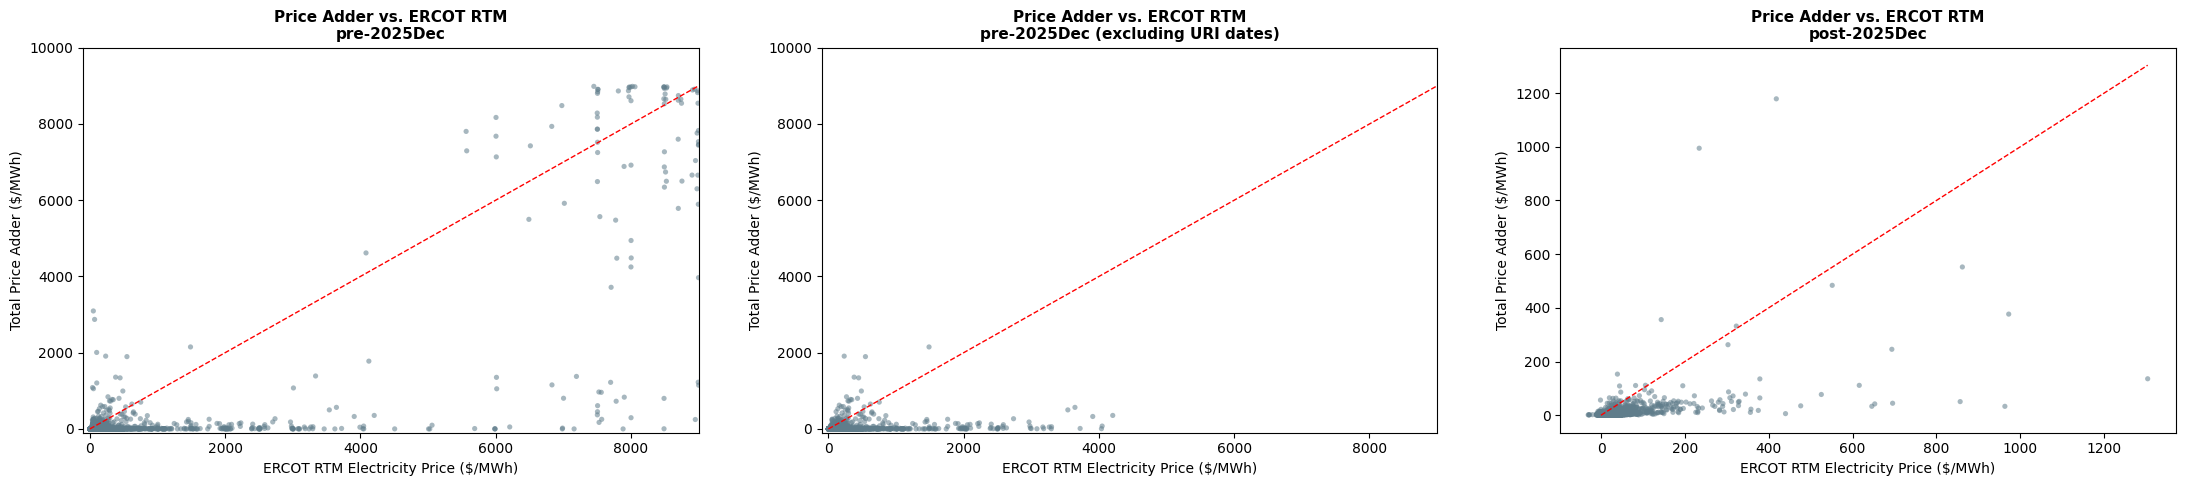

In [ ]:
# pre-2025 and post2025
pre_range = f"{df_pre2025['date'].min().strftime('%b %Y')} \u2013 {df_pre2025['date'].max().strftime('%b %Y')}"
post_range = f"{df_post2025['date'].min().strftime('%b %Y')} \u2013 {df_post2025['date'].max().strftime('%b %Y')}"

df_pre2025_no_uri = df_pre2025[~((df_pre2025['date'] >= '2021-02-14') & (df_pre2025['date'] <= '2022-02-25'))]

fig, axs = plt.subplots(1, 3, figsize=(27, 5))
axs[0].scatter(df_pre2025["rtm_price"], df_pre2025["adder_effective"], s=14, alpha=0.55, color="#607D8B", edgecolors="none")
axs[0].set_xlabel("ERCOT RTM Electricity Price ($/MWh)")
axs[0].set_ylabel("Total Price Adder ($/MWh)")
# draw 1:1 line for reference
max_price = max(df_pre2025["rtm_price"].max(), df_pre2025["adder_effective"].max())
axs[0].plot([0, max_price], [0, max_price], color='red', linestyle='--', linewidth=1)
axs[0].set_ylim(-100, 10000)
axs[0].set_xlim(-100, 9000)
axs[0].set_title(f"Price Adder vs. ERCOT RTM\npre-2025Dec", fontsize=11, fontweight="bold")

axs[1].scatter(df_pre2025_no_uri["rtm_price"], df_pre2025_no_uri["adder_effective"], s=14, alpha=0.55, color="#607D8B", edgecolors="none")
axs[1].set_xlabel("ERCOT RTM Electricity Price ($/MWh)")
axs[1].set_ylabel("Total Price Adder ($/MWh)")
axs[1].plot([0, max_price], [0, max_price], color='red', linestyle='--', linewidth=1)
axs[1].set_ylim(-100, 10000)
axs[1].set_xlim(-100, 9000)
axs[1].set_title(f"Price Adder vs. ERCOT RTM\npre-2025Dec (excluding URI dates)", fontsize=11, fontweight="bold")

axs[2].scatter(df_post2025["rtm_price"], df_post2025["adder_sum"], s=14, alpha=0.55, color="#607D8B", edgecolors="none")
axs[2].set_xlabel("ERCOT RTM Electricity Price ($/MWh)")
axs[2].set_ylabel("Total Price Adder ($/MWh)")
# draw 1:1 line for reference
max_price = max(df_post2025["rtm_price"].max(), df_post2025["adder_sum"].max())
axs[2].plot([0, max_price], [0, max_price], color='red', linestyle='--', linewidth=1)
axs[2].set_title(f"Price Adder vs. ERCOT RTM\npost-2025Dec", fontsize=11, fontweight="bold")
plt.savefig(OUT_DIR / "price_adder_correlations_rtm.png", dpi=150)
plt.show()

In [ ]:
df_pre2025[(df_pre2025['adder_effective'] > df_pre2025['rtm_price']) & (df_pre2025['adder_effective'] > 0)]

,date,RTRSVPOR,RTRSVPOFF,RTRDP,adder_sum,north_load,south_load,west_load,houston_load,total_load,rtm_price,adder_effective,RTRSVPOR_binary,RTRSVPOFF_binary,RTRDP_binary,adder_sum_binary
1113,2021-02-16 09:00:00,915.0350,724.8300,6605.4075,7520.4425,21478.79,13649.42,2932.48,7780.20,45840.89,7505.149333,7520.4425,1,1,1,1
1114,2021-02-16 10:00:00,308.5325,279.2650,7552.5975,7861.1300,20993.38,13378.18,2957.14,7544.04,44872.74,7503.576667,7861.1300,1,1,1,1
1115,2021-02-16 11:00:00,116.5425,112.5625,8061.6100,8178.1525,20503.05,13246.71,2839.58,7489.37,44078.71,7503.181333,8178.1525,1,1,1,1
1116,2021-02-16 12:00:00,379.3475,331.1325,7557.0000,7936.3475,20496.30,13159.92,2820.06,7526.72,44002.99,6828.862667,7936.3475,1,1,1,1
1117,2021-02-16 13:00:00,32.7525,30.2800,8138.2575,8171.0100,20534.38,13004.93,2844.51,7546.16,43929.98,6004.640667,8171.0100,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35487,2025-02-05 02:00:00,0.0000,0.0000,27.2925,27.2925,12631.15,10291.87,8443.67,10557.37,41924.06,18.802000,27.2925,0,0,1,1
35492,2025-02-05 07:00:00,0.0000,0.0000,36.0150,36.0150,14931.21,10846.31,7894.65,11390.23,45062.39,24.486667,36.0150,0,0,1,1
35832,2025-02-19 11:00:00,0.0000,0.0000,31.9725,31.9725,32432.33,19827.20,10423.31,15401.46,78084.30,28.686667,31.9725,0,0,1,1
36079,2025-03-01 18:00:00,2.1675,1.0900,77.0225,79.1900,14861.77,13116.95,8711.75,12632.68,49323.14,72.464000,79.1900,1,1,1,1


In [ ]:
# understand the abnormal section
df_adder_abnormal = df_pre2025_no_uri.copy()
df_adder_abnormal = df_adder_abnormal[df_adder_abnormal['adder_effective'] >= df_adder_abnormal['rtm_price']]
df_adder_abnormal.to_csv(OUT_DIR / "adder_abnormal_pre2025_no_uri.csv", index=False)

In [ ]:
df_adder_abnormal.describe().round(2)

,date,RTRSVPOR,RTRSVPOFF,RTRDP,adder_sum,north_load,south_load,west_load,houston_load,total_load,rtm_price,adder_effective
count,134,134.00,134.00,134.00,134.00,134.00,134.00,134.00,134.00,134.00,134.00,134.00
mean,2023-06-18 11:18:21.492537,171.31,78.60,57.70,307.61,19351.46,14533.13,7497.16,14016.01,55397.77,112.43,229.01
min,2022-03-03 06:00:00,0.00,0.00,0.00,0.00,11220.15,8940.78,5562.49,8502.60,34937.01,-2.66,0.00
25%,2022-07-13 19:15:00,0.00,0.00,0.00,0.00,14774.39,11557.70,6730.78,11343.76,46328.04,-0.15,0.00
50%,2023-02-11 12:00:00,49.18,0.10,8.88,87.32,17479.00,14293.86,7331.26,12871.56,52493.29,54.23,87.15
75%,2024-04-06 03:45:00,222.17,41.97,30.54,292.14,23823.92,17186.53,7839.97,16997.14,65150.79,145.24,249.58
max,2025-11-11 15:00:00,1883.02,1040.84,1957.36,2937.33,32432.33,21837.81,10423.31,20255.41,80521.72,1487.33,2150.39
std,NaN,293.63,175.99,233.85,520.68,5977.64,3639.75,1119.75,3367.56,12693.82,175.42,373.95


In [ ]:
abnormal_dates = df_adder_abnormal['date'].unique()
abnormal_dates.tolist()

[Timestamp('2022-03-03 06:00:00'),
 Timestamp('2022-03-03 07:00:00'),
 Timestamp('2022-03-15 19:00:00'),
 Timestamp('2022-04-04 20:00:00'),
 Timestamp('2022-04-04 21:00:00'),
 Timestamp('2022-04-10 13:00:00'),
 Timestamp('2022-04-10 14:00:00'),
 Timestamp('2022-04-22 09:00:00'),
 Timestamp('2022-04-22 10:00:00'),
 Timestamp('2022-04-22 13:00:00'),
 Timestamp('2022-04-22 14:00:00'),
 Timestamp('2022-04-22 15:00:00'),
 Timestamp('2022-04-22 16:00:00'),
 Timestamp('2022-05-13 14:00:00'),
 Timestamp('2022-05-13 15:00:00'),
 Timestamp('2022-05-13 16:00:00'),
 Timestamp('2022-05-13 17:00:00'),
 Timestamp('2022-07-08 15:00:00'),
 Timestamp('2022-07-08 17:00:00'),
 Timestamp('2022-07-09 15:00:00'),
 Timestamp('2022-07-09 16:00:00'),
 Timestamp('2022-07-09 17:00:00'),
 Timestamp('2022-07-09 18:00:00'),
 Timestamp('2022-07-09 19:00:00'),
 Timestamp('2022-07-09 20:00:00'),
 Timestamp('2022-07-10 18:00:00'),
 Timestamp('2022-07-10 19:00:00'),
 Timestamp('2022-07-12 14:00:00'),
 Timestamp('2022-07-

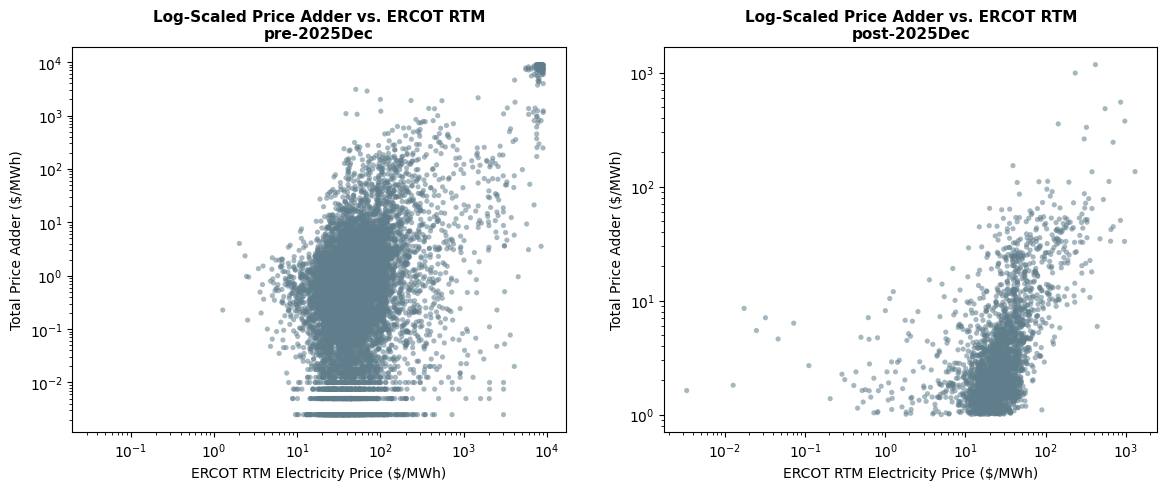

In [ ]:
# log scaled plots

# map 0-1 to 0 for log scale
df_pre2025["adder_sum"] = df_pre2025["adder_effective"].apply(lambda x: 0 if x <= 1 else x)
df_post2025["adder_sum"] = df_post2025["adder_sum"].apply(lambda x: 0 if x <= 1 else x)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].scatter(df_pre2025["rtm_price"], df_pre2025["adder_effective"], s=14, alpha=0.55, color="#607D8B", edgecolors="none")
axs[0].set_xlabel("ERCOT RTM Electricity Price ($/MWh)")
axs[0].set_ylabel("Total Price Adder ($/MWh)")
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_title(f"Log-Scaled Price Adder vs. ERCOT RTM\npre-2025Dec", fontsize=11, fontweight="bold")

axs[1].scatter(df_post2025["rtm_price"], df_post2025["adder_sum"], s=14, alpha=0.55, color="#607D8B", edgecolors="none")
axs[1].set_xlabel("ERCOT RTM Electricity Price ($/MWh)")
axs[1].set_ylabel("Total Price Adder ($/MWh)")
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_title(f"Log-Scaled Price Adder vs. ERCOT RTM\npost-2025Dec", fontsize=11, fontweight="bold")
plt.savefig(OUT_DIR / "price_adder_correlation_rtm_log.png", dpi=150)
plt.show()

## plot adder vs load with adder activation

In [ ]:
df_pre2025 = df_pre2025.copy()
df_pre2025['RTRSVPOR_binary'] = (df_pre2025['RTRSVPOR'] != 0).astype(int)
df_pre2025['RTRSVPOFF_binary'] = (df_pre2025['RTRSVPOFF'] != 0).astype(int)
df_pre2025['RTRDP_binary'] = (df_pre2025['RTRDP'] != 0).astype(int)
df_pre2025['adder_sum_binary'] = (df_pre2025['adder_sum'] != 0).astype(int)
df_pre2025

,date,RTRSVPOR,RTRSVPOFF,RTRDP,adder_sum,north_load,south_load,west_load,houston_load,total_load,rtm_price,adder_effective,RTRSVPOR_binary,RTRSVPOFF_binary,RTRDP_binary,adder_sum_binary
0,2021-01-01 00:00:00,0.0,0.0,0.0,0.0,16349.98,12373.92,5540.13,10246.37,44510.41,18.714000,0.0,0,0,0,0
1,2021-01-01 01:00:00,0.0,0.0,0.0,0.0,15893.68,12238.90,5477.28,10103.94,43713.80,18.107333,0.0,0,0,0,0
2,2021-01-01 02:00:00,0.0,0.0,0.0,0.0,15616.31,12216.98,5436.11,10044.96,43314.37,17.570000,0.0,0,0,0,0
3,2021-01-01 03:00:00,0.0,0.0,0.0,0.0,15572.19,12089.64,5392.11,9994.41,43048.35,17.670667,0.0,0,0,0,0
4,2021-01-01 04:00:00,0.0,0.0,0.0,0.0,15666.11,12001.46,5356.96,10049.11,43073.65,17.792000,0.0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42727,2025-12-03 20:00:00,0.0,0.0,0.0,0.0,18435.39,13732.00,9344.98,12656.88,54169.25,38.510667,0.0,0,0,0,0
42728,2025-12-03 21:00:00,0.0,0.0,0.0,0.0,18427.63,13546.22,9332.75,12497.16,53803.77,32.500667,0.0,0,0,0,0
42729,2025-12-03 22:00:00,0.0,0.0,0.0,0.0,18347.67,13186.72,9190.78,12141.89,52867.06,32.682000,0.0,0,0,0,0
42730,2025-12-03 23:00:00,0.0,0.0,0.0,0.0,17461.15,12730.07,9124.12,11709.78,51025.12,31.134667,0.0,0,0,0,0


/var/folders/0q/ndh_pk0s37n95y6svtjfy7hw0000gp/T/ipykernel_5002/1466869220.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


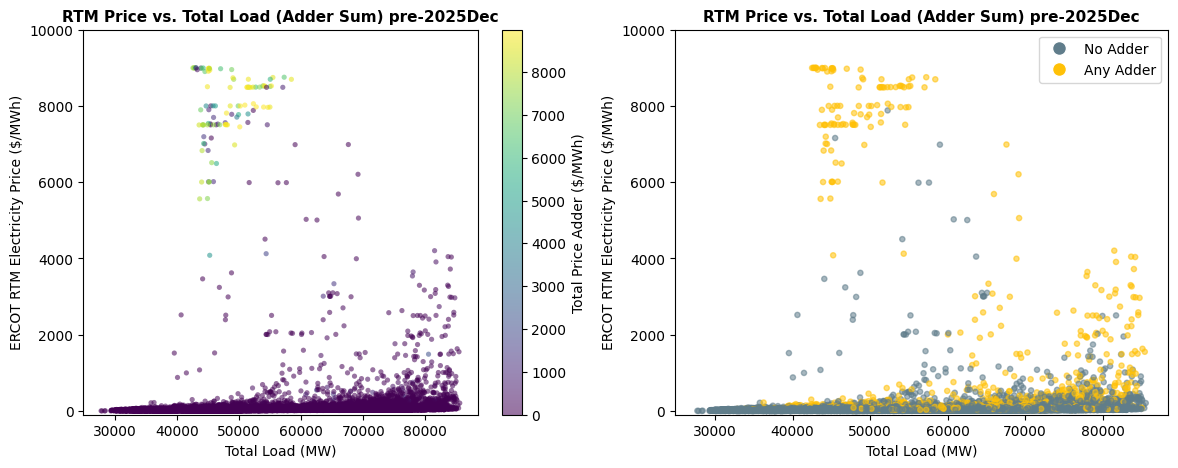

In [ ]:
# adder vs. load
from matplotlib.colors import ListedColormap
from matplotlib.pyplot import scatter

# total adders
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
scatter_plot = axs[0].scatter(df_pre2025["total_load"], df_pre2025["rtm_price"], s=14, alpha=0.55, c=df_pre2025["adder_effective"], cmap="viridis", edgecolors="none")
axs[0].set_xlabel("Total Load (MW)")
axs[0].set_ylabel("ERCOT RTM Electricity Price ($/MWh)")
axs[0].set_ylim(-100, 10000)
axs[0].set_title(f"RTM Price vs. Total Load (Adder Sum) pre-2025Dec", fontsize=11, fontweight="bold")
plt.colorbar(scatter_plot, label="Total Price Adder ($/MWh)", ax=axs[0])

axs[1].scatter(df_pre2025["total_load"], df_pre2025["rtm_price"], s=14, alpha=0.55, c=df_pre2025["adder_sum_binary"], cmap=ListedColormap(["#607D8B", "#FFC107"]))
axs[1].set_xlabel("Total Load (MW)")
axs[1].set_ylabel("ERCOT RTM Electricity Price ($/MWh)")
axs[1].set_ylim(-100, 10000)
axs[1].set_title(f"RTM Price vs. Total Load (Adder Sum) pre-2025Dec", fontsize=11, fontweight="bold")
axs[1].legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label='No Adder', markerfacecolor='#607D8B', markersize=10),
                plt.Line2D([0], [0], marker='o', color='w', label='Any Adder', markerfacecolor='#FFC107', markersize=10)])
fig.savefig(OUT_DIR / "price_adder_rtm_load_correlation_pre2025.png", dpi=150)
fig.show()

In [5]:
df_pre2025

NameError: name 'df_pre2025' is not defined

In [32]:
df_filter = df_pre2025[(df_pre2025["total_load"] < 60000) & (df_pre2025["rtm_price"] > 6000)]
df_filter['date']

1064   2021-02-14 08:00:00
1085   2021-02-15 05:00:00
1086   2021-02-15 06:00:00
1087   2021-02-15 07:00:00
1088   2021-02-15 08:00:00
               ...        
1182   2021-02-19 06:00:00
1183   2021-02-19 07:00:00
1184   2021-02-19 08:00:00
1185   2021-02-19 09:00:00
1186   2021-02-19 10:00:00
Name: date, Length: 100, dtype: datetime64[us]

/var/folders/0q/ndh_pk0s37n95y6svtjfy7hw0000gp/T/ipykernel_5002/3623948825.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


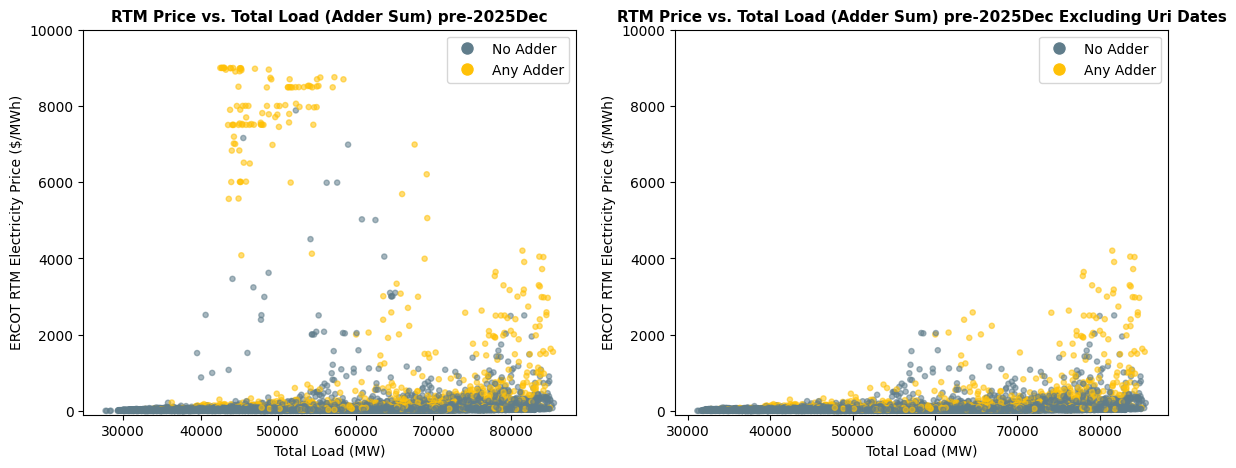

In [23]:
# dates excluding (2021, 2, 14) to (2022, 2, 25)
df_filter = df_pre2025[~((df_pre2025['date'] >= '2021-02-14') & (df_pre2025['date'] <= '2022-02-25'))]

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].scatter(df_pre2025["total_load"], df_pre2025["rtm_price"], s=14, alpha=0.55, c=df_pre2025["adder_sum_binary"], cmap=ListedColormap(["#607D8B", "#FFC107"]))
axs[0].set_xlabel("Total Load (MW)")
axs[0].set_ylabel("ERCOT RTM Electricity Price ($/MWh)")
axs[0].set_ylim(-100, 10000)
axs[0].set_title(f"RTM Price vs. Total Load (Adder Sum) pre-2025Dec", fontsize=11, fontweight="bold")
axs[0].legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label='No Adder', markerfacecolor='#607D8B', markersize=10),
                plt.Line2D([0], [0], marker='o', color='w', label='Any Adder', markerfacecolor='#FFC107', markersize=10)])

axs[1].scatter(df_filter["total_load"], df_filter["rtm_price"], s=14, alpha=0.55, c=df_filter["adder_sum_binary"], cmap=ListedColormap(["#607D8B", "#FFC107"]))
axs[1].set_xlabel("Total Load (MW)")
axs[1].set_ylabel("ERCOT RTM Electricity Price ($/MWh)")
axs[1].set_ylim(-100, 10000)
axs[1].set_title(f"RTM Price vs. Total Load (Adder Sum) pre-2025Dec Excluding Uri Dates", fontsize=11, fontweight="bold")
axs[1].legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label='No Adder', markerfacecolor='#607D8B', markersize=10),
                plt.Line2D([0], [0], marker='o', color='w', label='Any Adder', markerfacecolor='#FFC107', markersize=10)])
fig.savefig(OUT_DIR / "price_adder_rtm_load_correlation_pre2025_excluding_uri_dates.png", dpi=150)
fig.show()

/var/folders/0q/ndh_pk0s37n95y6svtjfy7hw0000gp/T/ipykernel_35225/1780019789.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


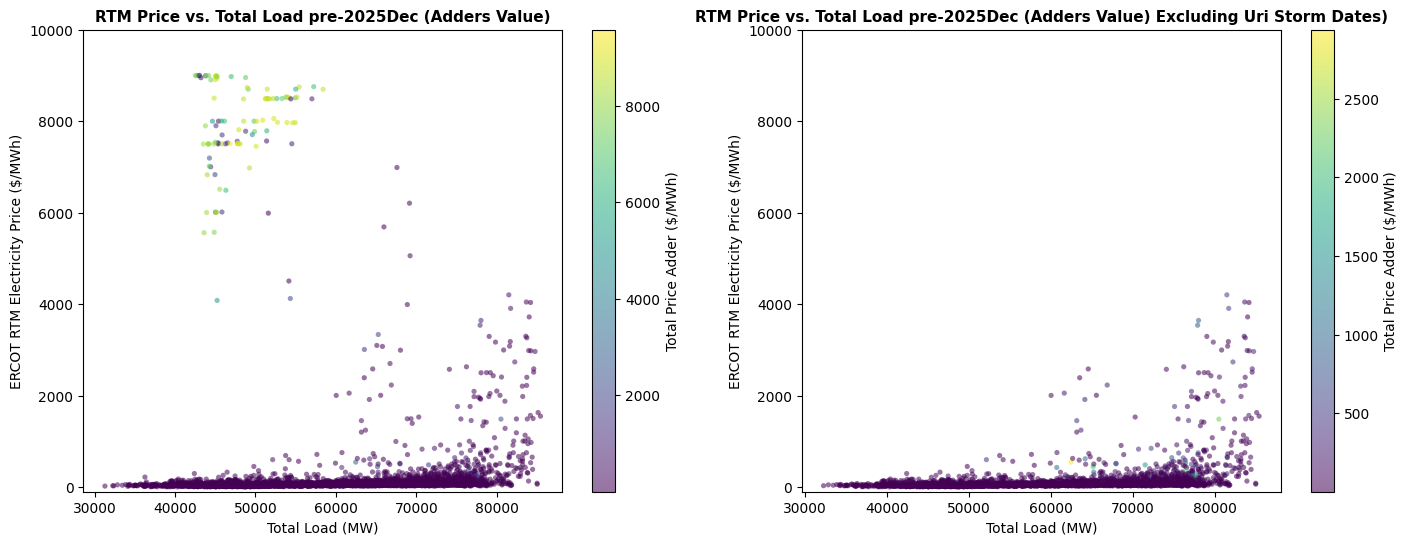

In [ ]:
df_filter_with_adder = df_pre2025[df_pre2025["adder_sum_binary"] == 1]
df_no_storm = df_filter_with_adder[~((df_filter_with_adder['date'] >= '2021-02-14') & (df_filter_with_adder['date'] <= '2022-02-25'))]

fig, axs = plt.subplots(1, 2, figsize=(17, 6))
scatter_plot = axs[0].scatter(df_filter_with_adder["total_load"], df_filter_with_adder["rtm_price"], s=14, alpha=0.55, c=df_filter_with_adder["adder_sum"], cmap="viridis", edgecolors="none")
axs[0].set_xlabel("Total Load (MW)")
axs[0].set_ylabel("ERCOT RTM Electricity Price ($/MWh)")
axs[0].set_ylim(-100, 10000)
axs[0].set_title(f"RTM Price vs. Total Load pre-2025Dec (Adders Value)", fontsize=11, fontweight="bold")
plt.colorbar(scatter_plot, label="Total Price Adder ($/MWh)", ax=axs[0])

scatter_plot = axs[1].scatter(df_no_storm["total_load"], df_no_storm["rtm_price"], s=14, alpha=0.55, c=df_no_storm["adder_sum"], cmap="viridis", edgecolors="none")
axs[1].set_xlabel("Total Load (MW)")
axs[1].set_ylabel("ERCOT RTM Electricity Price ($/MWh)")
axs[1].set_ylim(-100, 10000)
axs[1].set_title(f"RTM Price vs. Total Load pre-2025Dec (Adders Value) Excluding Uri Storm Dates)", fontsize=11, fontweight="bold")
plt.colorbar(scatter_plot, label="Total Price Adder ($/MWh)", ax=axs[1])
fig.savefig(OUT_DIR / "price_adder_rtm_load_correlation_pre2025_colored_uri_comparison.png", dpi=150)
fig.show()

In [24]:
# identify the values with high adders
df_pre2025['date'] = pd.to_datetime(df_pre2025['date'])

for threshold in [1000, 2000, 3000, 4000]:
    df_pre2025_adder_over_threshold = df_pre2025[df_pre2025["adder_sum"] > threshold]
    date_counts = df_pre2025_adder_over_threshold['date'].dt.date.nunique()
    print(f"\nnumber of dates when adders > {threshold}: {date_counts}")
    print(df_pre2025_adder_over_threshold['date'].dt.date.unique())



number of dates when adders > 1000: 11
[datetime.date(2021, 2, 15) datetime.date(2021, 2, 16)
 datetime.date(2021, 2, 17) datetime.date(2021, 2, 18)
 datetime.date(2021, 2, 19) datetime.date(2022, 2, 23)
 datetime.date(2022, 2, 24) datetime.date(2022, 5, 13)
 datetime.date(2022, 7, 9) datetime.date(2022, 7, 13)
 datetime.date(2023, 8, 17)]

number of dates when adders > 2000: 7
[datetime.date(2021, 2, 15) datetime.date(2021, 2, 16)
 datetime.date(2021, 2, 17) datetime.date(2021, 2, 18)
 datetime.date(2021, 2, 19) datetime.date(2022, 2, 24)
 datetime.date(2023, 8, 17)]

number of dates when adders > 3000: 6
[datetime.date(2021, 2, 15) datetime.date(2021, 2, 16)
 datetime.date(2021, 2, 17) datetime.date(2021, 2, 18)
 datetime.date(2021, 2, 19) datetime.date(2022, 2, 24)]

number of dates when adders > 4000: 5
[datetime.date(2021, 2, 15) datetime.date(2021, 2, 16)
 datetime.date(2021, 2, 17) datetime.date(2021, 2, 18)
 datetime.date(2021, 2, 19)]


/var/folders/0q/ndh_pk0s37n95y6svtjfy7hw0000gp/T/ipykernel_5002/3973440991.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


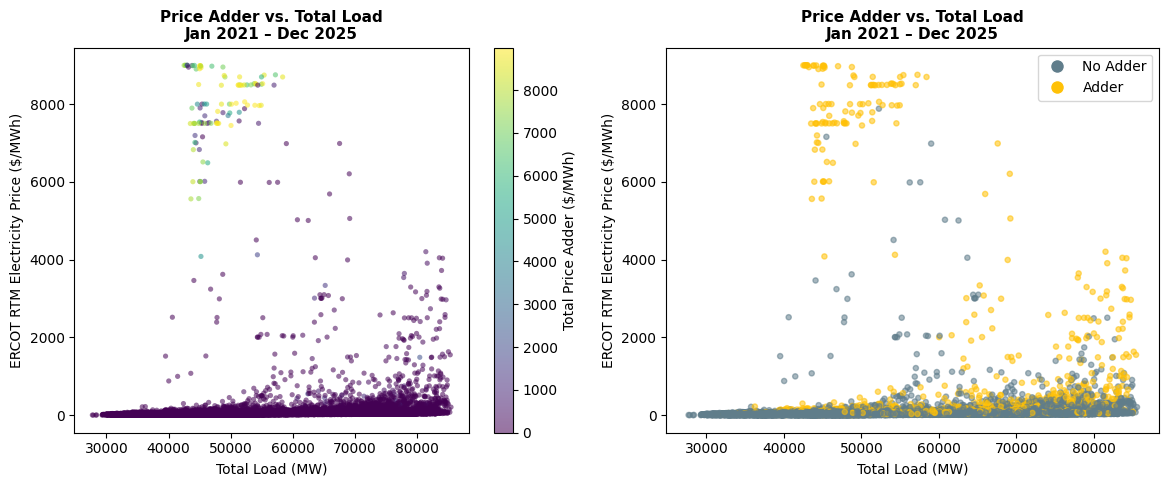

In [26]:
# total adders
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
scatter_plot = axs[0].scatter(df_pre2025["total_load"], df_pre2025["rtm_price"], s=14, alpha=0.55, c=df_pre2025["adder_effective"], cmap="viridis", edgecolors="none")
axs[0].set_xlabel("Total Load (MW)")
axs[0].set_ylabel("ERCOT RTM Electricity Price ($/MWh)")
axs[0].set_title(f"Price Adder vs. Total Load\n{pre_range}", fontsize=11, fontweight="bold")
plt.colorbar(scatter_plot, label="Total Price Adder ($/MWh)", ax=axs[0])

axs[1].scatter(df_pre2025["total_load"], df_pre2025["rtm_price"], s=14, alpha=0.55, c=df_pre2025["adder_sum_binary"], cmap=ListedColormap(["#607D8B", "#FFC107"]))
axs[1].set_xlabel("Total Load (MW)")
axs[1].set_ylabel("ERCOT RTM Electricity Price ($/MWh)")
axs[1].set_title(f"Price Adder vs. Total Load\n{pre_range}", fontsize=11, fontweight="bold")
axs[1].legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label='No Adder', markerfacecolor='#607D8B', markersize=10),
                plt.Line2D([0], [0], marker='o', color='w', label='Adder', markerfacecolor='#FFC107', markersize=10)])
fig.savefig(OUT_DIR / "price_adder_rtm_load_correlation_pre2025.png", dpi=150)
fig.show()

/var/folders/0q/ndh_pk0s37n95y6svtjfy7hw0000gp/T/ipykernel_21341/1589198737.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


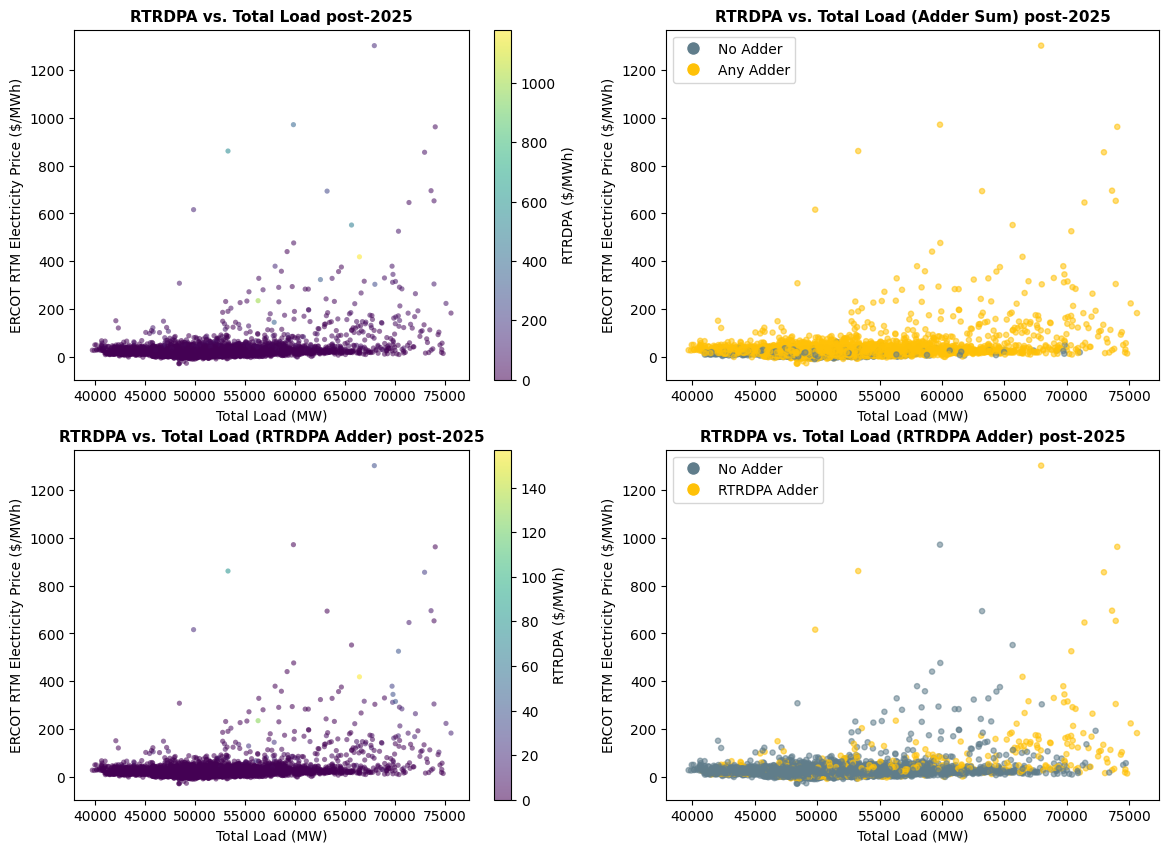

In [77]:
# post2025 adder vs. load
df_post2025 = df_post2025.copy()
df_post2025['RTRDPA_binary'] = (df_post2025['RTRDPA'] != 0).astype(int)
df_post2025['RTRDPRU_binary'] = (df_post2025['RTRDPRU'] != 0).astype(int)
df_post2025['RTRDPRD_binary'] = (df_post2025['RTRDPRD'] != 0).astype(int)
df_post2025['RTRDPRRS_binary'] = (df_post2025['RTRDPRRS'] != 0).astype(int)
df_post2025['RTRDPECRS_binary'] = (df_post2025['RTRDPECRS'] != 0).astype(int)
df_post2025['RTRDPNS_binary'] = (df_post2025['RTRDPNS'] != 0).astype(int)
df_post2025['adder_sum_binary'] = (df_post2025['adder_sum'] != 0).astype(int)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
scatter_plot = axs[0, 0].scatter(df_post2025["total_load"], df_post2025["rtm_price"], s=14, alpha=0.55, c=df_post2025["adder_sum"], cmap="viridis", edgecolors="none")
axs[0, 0].set_xlabel("Total Load (MW)")
axs[0, 0].set_ylabel("ERCOT RTM Electricity Price ($/MWh)")
axs[0, 0].set_title(f"RTRDPA vs. Total Load post-2025", fontsize=11, fontweight="bold")
plt.colorbar(scatter_plot, label="RTRDPA ($/MWh)", ax=axs[0, 0])

axs[0, 1].scatter(df_post2025["total_load"], df_post2025["rtm_price"], s=14, alpha=0.55, c=df_post2025["adder_sum_binary"], cmap=ListedColormap(["#607D8B", "#FFC107"]))
axs[0, 1].set_xlabel("Total Load (MW)")
axs[0, 1].set_ylabel("ERCOT RTM Electricity Price ($/MWh)")
axs[0, 1].set_title(f"RTRDPA vs. Total Load (Adder Sum) post-2025", fontsize=11, fontweight="bold")
axs[0, 1].legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label='No Adder', markerfacecolor='#607D8B', markersize=10),
                plt.Line2D([0], [0], marker='o', color='w', label='Any Adder', markerfacecolor='#FFC107', markersize=10)])

scatter_plot = axs[1, 0].scatter(df_post2025["total_load"], df_post2025["rtm_price"], s=14, alpha=0.55, c=df_post2025["RTRDPA"], cmap="viridis", edgecolors="none")
axs[1, 0].set_xlabel("Total Load (MW)")
axs[1, 0].set_ylabel("ERCOT RTM Electricity Price ($/MWh)")
axs[1, 0].set_title(f"RTRDPA vs. Total Load (RTRDPA Adder) post-2025", fontsize=11, fontweight="bold")
plt.colorbar(scatter_plot, label="RTRDPA ($/MWh)", ax=axs[1, 0])

axs[1, 1].scatter(df_post2025["total_load"], df_post2025["rtm_price"], s=14, alpha=0.55, c=df_post2025["RTRDPA_binary"], cmap=ListedColormap(["#607D8B", "#FFC107"]))
axs[1, 1].set_xlabel("Total Load (MW)")
axs[1, 1].set_ylabel("ERCOT RTM Electricity Price ($/MWh)")
axs[1, 1].set_title(f"RTRDPA vs. Total Load (RTRDPA Adder) post-2025", fontsize=11, fontweight="bold")
axs[1, 1].legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label='No Adder', markerfacecolor='#607D8B', markersize=10),
                plt.Line2D([0], [0], marker='o', color='w', label='RTRDPA Adder', markerfacecolor='#FFC107', markersize=10)])


plt.savefig(OUT_DIR / "price_adder_rtm_load_correlation_post2025.png", dpi=150)
fig.show()